# Exploracion del dataset marketing_raw

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
DataOriginal =pd.read_csv("marketing_raw.csv")
DO = DataOriginal

# 1. Análisis Exploratorio de Datos (EDA)

## Estructura del DataSet


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print("Dimension del DataSet:", DO.shape)
print("\nPrimeras filas:")
DO.head()


Dimension del DataSet: (2205, 39)

Primeras filas:


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,$58138,0,0,58,$635,$88,$546,$172,$88,$88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,1,0,0,$1529,1441,0
1,$46344,1,1,38,$11,$1,$6,$2,$1,$6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,1,0,0,$21,15,0
2,$71613,0,0,26,$426,$49,$127,$111,$21,$42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,1,0,0,$734,692,0
3,$26646,1,0,26,$11,$4,$20,$10,$3,$5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,1,0,0,$48,43,0
4,$58293,1,0,94,$173,$43,$118,$46,$27,$15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,$407,392,0


In [4]:
DO.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Income                2205 non-null   object
 1   Kidhome               2205 non-null   int64 
 2   Teenhome              2205 non-null   int64 
 3   Recency               2205 non-null   int64 
 4   MntWines              2205 non-null   object
 5   MntFruits             2205 non-null   object
 6   MntMeatProducts       2205 non-null   object
 7   MntFishProducts       2205 non-null   object
 8   MntSweetProducts      2205 non-null   object
 9   MntGoldProds          2205 non-null   object
 10  NumDealsPurchases     2205 non-null   int64 
 11  NumWebPurchases       2205 non-null   int64 
 12  NumCatalogPurchases   2205 non-null   int64 
 13  NumStorePurchases     2205 non-null   int64 
 14  NumWebVisitsMonth     2205 non-null   int64 
 15  AcceptedCmp3          2205 non-null   

In [5]:
print(DO.columns)

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')


## VALORES NULOS

In [6]:
Nulos = DO.isnull().sum().to_frame(name="Nulos")
Nulos_T = Nulos.T
print("Sin valores nulos detectados:" if Nulos.sum().sum() == 0 else "Valores nulos encontrados:")
Nulos_T

Sin valores nulos detectados:


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
Nulos,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Duplicados

In [7]:
print("Total de filas duplicadas:", DO.duplicated().sum())
print("Porcentaje:", round(DO.duplicated().sum() / len(DO) * 100, 2), "%")

Total de filas duplicadas: 184
Porcentaje: 8.34 %


In [8]:
# Valores duplicados por columna
Duplicados_Columna = {}
for columna in DO.columns:
    Duplicados_Columna[columna] = DO[columna].duplicated().sum()

Duplicados_df = pd.DataFrame.from_dict(Duplicados_Columna, orient="index", columns=["Duplicados"])
Duplicados_df.sort_values(by="Duplicados", ascending=False).T
print("Porcentaje de duplicados")

Porcentaje de duplicados


**Observaciones sobre la calidad del dataset**

- **Columnas monetarias con símbolo `$`**: `Income`, `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds`, `MntTotal` son de tipo `object` y deben convertirse a numérico.
- **184 filas duplicadas (8.3% del total)**: deben eliminarse para evitar sesgo en el análisis.
- **`education_2n Cycle`**: columna binaria no incluida en el diccionario de datos original. Se mapeará como `'2n Cycle'` en la variable `Education`.
- **`Age = 99999`**: el enunciado del proyecto menciona edades inválidas con ese valor. En este dataset no se detectan. Se incluye validación defensiva.
- **`Z_CostContact` / `Z_Revenue`**: columnas constantes sin valor analítico. Se eliminarán.


# 2. Preprocesamiento de Datos

In [9]:
# Trabajamos sobre una copia para preservar el dataset original
DataCopia = DO.copy()
DC = DataCopia

**Conversión de columnas monetarias**

In [10]:
columns_monetarias = ["Income", "MntWines", "MntFruits", "MntMeatProducts",
                      "MntFishProducts", "MntSweetProducts", "MntGoldProds", "MntTotal"]
DC[columns_monetarias] = DC[columns_monetarias].replace(r"[\$,]", "", regex=True).astype(float)
print("Tipos de datos después de la conversión:")
DC[columns_monetarias].dtypes

Tipos de datos después de la conversión:


Income              float64
MntWines            float64
MntFruits           float64
MntMeatProducts     float64
MntFishProducts     float64
MntSweetProducts    float64
MntGoldProds        float64
MntTotal            float64
dtype: object

**Creacion de id_cliente**

In [11]:
# Se inserta un identificador único secuencial para cada cliente
if "id_cliente" not in DC.columns:
    DC.insert(0, "id_cliente", range(1, len(DC) + 1))
print("Columnas actuales:", DC.shape)
DC.head(3)



Columnas actuales: (2205, 40)


,id_cliente,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,1,58138.0,0,0,58,635.0,88.0,546.0,172.0,88.0,88.0,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,1,0,0,1529.0,1441,0
1,2,46344.0,1,1,38,11.0,1.0,6.0,2.0,1.0,6.0,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,1,0,0,21.0,15,0
2,3,71613.0,0,0,26,426.0,49.0,127.0,111.0,21.0,42.0,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,1,0,0,734.0,692,0


### CONSTRUCCION DE LAS COLUMNAS BINARIAS


**Marital_Status** 

In [13]:
if "Marital_Status" not in DC.columns:
    conditions_marital = [
        (DC["marital_Single"] == 1),
        (DC["marital_Married"] == 1),
        (DC["marital_Together"] == 1),
        (DC["marital_Divorced"] == 1),
        (DC["marital_Widow"] == 1)
    ]
    choices_marital = ["Single", "Married", "Together", "Divorced", "Widow"]
    DC["Marital_Status"] = np.select(conditions_marital, choices_marital, default="Unknown")

print(DC["Marital_Status"].value_counts())

Marital_Status
Married     854
Together    568
Single      477
Divorced    230
Widow        76
Name: count, dtype: int64


**Education**

In [15]:
if "Education" not in DC.columns:
    conditions_edu = [
        (DC["education_Basic"] == 1),
        (DC["education_Graduation"] == 1),
        (DC["education_Master"] == 1),
        (DC["education_PhD"] == 1),
        (DC["education_2n Cycle"] == 1)
    ]
    choices_edu = ["Basic", "Graduation", "Master", "PhD", "2n Cycle"]
    DC["Education"] = np.select(conditions_edu, choices_edu, default="Unknown")

print(DC["Education"].value_counts())

Education
Graduation    1113
PhD            476
Master         364
2n Cycle       198
Basic           54
Name: count, dtype: int64


**Eliminación de columnas binarias originales**


In [16]:
cols_a_eliminar = [
    "marital_Single", "marital_Married", "marital_Together", "marital_Divorced", "marital_Widow",
    "education_Basic", "education_Graduation", "education_Master", "education_PhD", "education_2n Cycle"
]
DC = DC.drop(columns=cols_a_eliminar, errors="ignore")
print("Columnas después del drop:", DC.shape[1])
DC.head(3)

Columnas después del drop: 32


,id_cliente,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,MntTotal,MntRegularProds,AcceptedCmpOverall,Marital_Status,Education
0,1,58138.0,0,0,58,635.0,88.0,546.0,172.0,88.0,88.0,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,1529.0,1441,0,Single,Graduation
1,2,46344.0,1,1,38,11.0,1.0,6.0,2.0,1.0,6.0,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,21.0,15,0,Single,Graduation
2,3,71613.0,0,0,26,426.0,49.0,127.0,111.0,21.0,42.0,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,734.0,692,0,Together,Graduation


In [26]:
print("Cantidad de datos")
print(DC["Marital_Status"].value_counts())

Cantidad de datos
Marital_Status
Married     854
Together    568
Single      477
Divorced    230
Widow        76
Name: count, dtype: int64


In [27]:
print("Cantidad de datos")
print("Cantidad de datos",DC["Education"].value_counts())

Cantidad de datos
Cantidad de datos Education
Graduation    1113
PhD            476
Master         364
2n Cycle       198
Basic           54
Name: count, dtype: int64


# 4.Tratamiento de Valores Inválidos

In [28]:
# El enunciado indica posibles valores 99999 en Age (error de captura/placeholder)
n_invalidos = (DC["Age"] == 99999).sum()
print(f"Registros con Age = 99999: {n_invalidos}")

if n_invalidos > 0:
    mediana_age = DC.loc[DC["Age"] != 99999, "Age"].median()
    DC.loc[DC["Age"] == 99999, "Age"] = mediana_age
    print(f"  → Reemplazados por la mediana: {mediana_age}")
else:
    print("  → No se encontraron valores inválidos. No se requiere acción.")

print("\nEstadísticas de Age:")
print(DC["Age"].describe())

Registros con Age = 99999: 0
  → No se encontraron valores inválidos. No se requiere acción.

Estadísticas de Age:
count    2205.000000
mean       51.095692
std        11.705801
min        24.000000
25%        43.000000
50%        50.000000
75%        61.000000
max        80.000000
Name: Age, dtype: float64


# **5. Validaciones Finales**

## Verificación de tipos de datso

In [29]:
DC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           2205 non-null   int64  
 1   Income               2205 non-null   float64
 2   Kidhome              2205 non-null   int64  
 3   Teenhome             2205 non-null   int64  
 4   Recency              2205 non-null   int64  
 5   MntWines             2205 non-null   float64
 6   MntFruits            2205 non-null   float64
 7   MntMeatProducts      2205 non-null   float64
 8   MntFishProducts      2205 non-null   float64
 9   MntSweetProducts     2205 non-null   float64
 10  MntGoldProds         2205 non-null   float64
 11  NumDealsPurchases    2205 non-null   int64  
 12  NumWebPurchases      2205 non-null   int64  
 13  NumCatalogPurchases  2205 non-null   int64  
 14  NumStorePurchases    2205 non-null   int64  
 15  NumWebVisitsMonth    2205 non-null   i

## Estadísticas descriptivas

In [30]:
DC[["Income", "Age", "Kidhome", "Teenhome", "Customer_Days", "MntTotal"]].describe()

,Income,Age,Kidhome,Teenhome,Customer_Days,MntTotal
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,51622.094785,51.095692,0.442177,0.506576,2512.718367,562.764626
std,20713.063826,11.705801,0.537132,0.544380,202.563647,575.936911
min,1730.000000,24.000000,0.000000,0.000000,2159.000000,4.000000
25%,35196.000000,43.000000,0.000000,0.000000,2339.000000,56.000000
50%,51287.000000,50.000000,0.000000,0.000000,2515.000000,343.000000
75%,68281.000000,61.000000,1.000000,1.000000,2688.000000,964.000000
max,113734.000000,80.000000,2.000000,2.000000,2858.000000,2491.000000


In [31]:
print("Distribución Marital_Status:")
print(DC["Marital_Status"].value_counts(normalize=True).round(4))
print("\nDistribución Education:")
print(DC["Education"].value_counts(normalize=True).round(4))

Distribución Marital_Status:
Marital_Status
Married     0.3873
Together    0.2576
Single      0.2163
Divorced    0.1043
Widow       0.0345
Name: proportion, dtype: float64

Distribución Education:
Education
Graduation    0.5048
PhD           0.2159
Master        0.1651
2n Cycle      0.0898
Basic         0.0245
Name: proportion, dtype: float64


In [32]:
# Verificación final de nulos
nulos_final = DC.isnull().sum()
print("Nulos por columna:")
print(nulos_final[nulos_final > 0] if nulos_final.sum() > 0 else "Sin valores nulos.")


Nulos por columna:
Sin valores nulos.


# Matriz de correlación

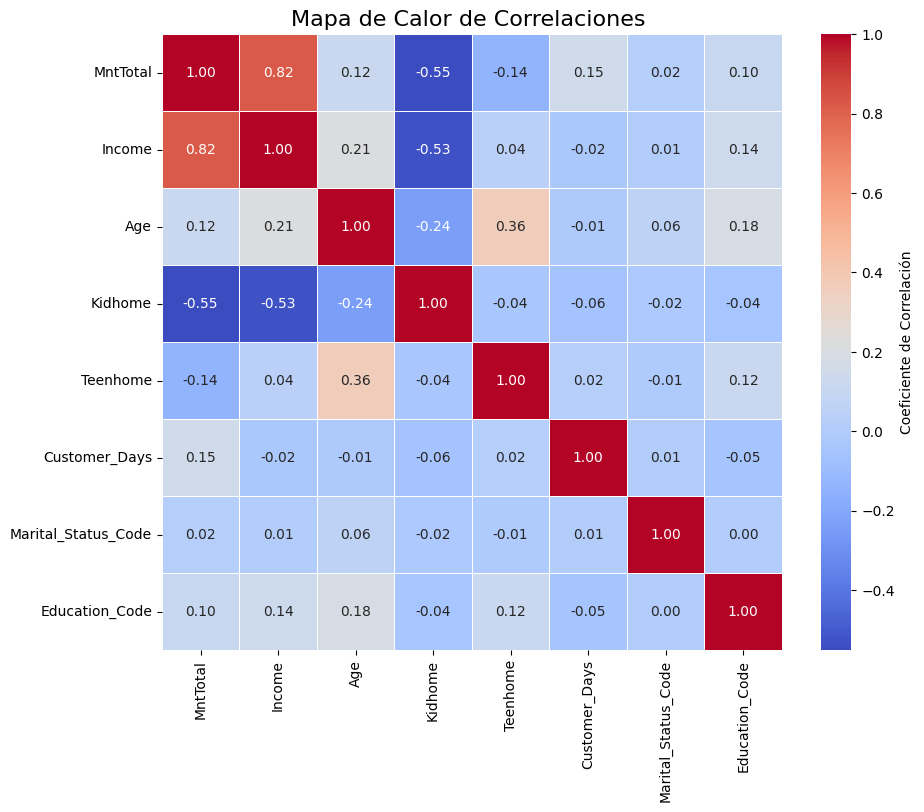

In [42]:
DC["Marital_Status_Code"] = DC["Marital_Status"].astype("category").cat.codes
DC["Education_Code"] = DC["Education"].astype("category").cat.codes

corr_cols = ["MntTotal", "Income", "Age", "Kidhome", "Teenhome", "Customer_Days",
             "Marital_Status_Code", "Education_Code"]
DC[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    DC[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Mapa de Calor de Correlaciones ', fontsize=16)
plt.show()

In [43]:
DC[["MntTotal","Income","Age","Kidhome","Teenhome","Customer_Days","Marital_Status_Code","Education_Code"]].corr()


,MntTotal,Income,Age,Kidhome,Teenhome,Customer_Days,Marital_Status_Code,Education_Code
MntTotal,1.000000,0.823066,0.118370,-0.551152,-0.142995,0.150476,0.021059,0.103880
Income,0.823066,1.000000,0.212625,-0.531699,0.042483,-0.024892,0.011213,0.137973
Age,0.118370,0.212625,1.000000,-0.238083,0.362919,-0.013462,0.059774,0.184467
Kidhome,-0.551152,-0.531699,-0.238083,1.000000,-0.040207,-0.055743,-0.020160,-0.044368
Teenhome,-0.142995,0.042483,0.362919,-0.040207,1.000000,0.019394,-0.007921,0.121324
Customer_Days,0.150476,-0.024892,-0.013462,-0.055743,0.019394,1.000000,0.007564,-0.051247
Marital_Status_Code,0.021059,0.011213,0.059774,-0.020160,-0.007921,0.007564,1.000000,0.003157
Education_Code,0.103880,0.137973,0.184467,-0.044368,0.121324,-0.051247,0.003157,1.000000


## 5.1. Análisis de Outliers (columnas clave)

In [44]:
Columnas_Clave = ["Income", "Age", "Customer_Days", "MntTotal"]

Cuartiles_Dict = {}
for columna in Columnas_Clave:
    if columna in DC.columns:
        Q1 = DC[columna].quantile(0.25)
        Q2 = DC[columna].quantile(0.50)
        Q3 = DC[columna].quantile(0.75)
        IQR = Q3 - Q1
        Limite_Inf = Q1 - 1.5 * IQR
        Limite_Sup = Q3 + 1.5 * IQR
        outliers_bajos = DC[DC[columna] < Limite_Inf].shape[0]
        outliers_altos = DC[DC[columna] > Limite_Sup].shape[0]
        Cuartiles_Dict[columna] = {
            "Q1": round(Q1, 2), "Mediana": round(Q2, 2), "Q3": round(Q3, 2),
            "IQR": round(IQR, 2), "Outliers bajos": outliers_bajos,
            "Outliers altos": outliers_altos, "Total outliers": outliers_bajos + outliers_altos
        }

cuartiles_df = pd.DataFrame.from_dict(Cuartiles_Dict, orient="index")
cuartiles_df.sort_values(by="Total outliers", ascending=False)

,Q1,Mediana,Q3,IQR,Outliers bajos,Outliers altos,Total outliers
MntTotal,56.0,343.0,964.0,908.0,0,3,3
Income,35196.0,51287.0,68281.0,33085.0,0,0,0
Age,43.0,50.0,61.0,18.0,0,0,0
Customer_Days,2339.0,2515.0,2688.0,349.0,0,0,0


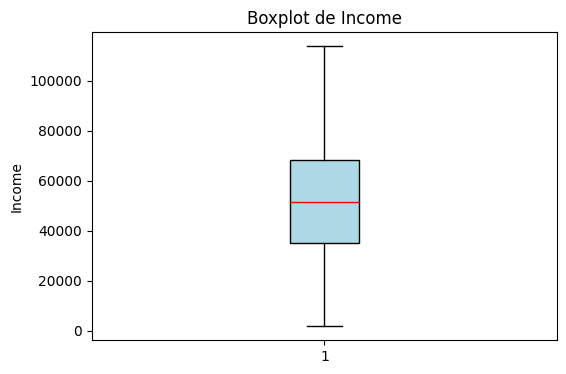

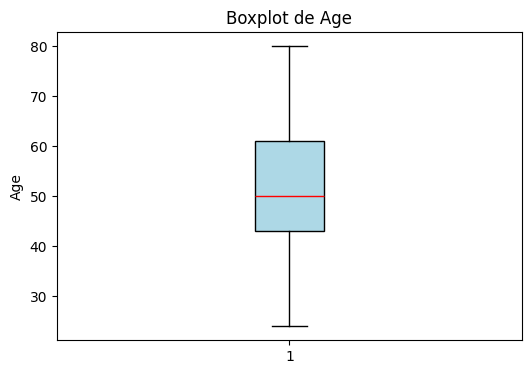

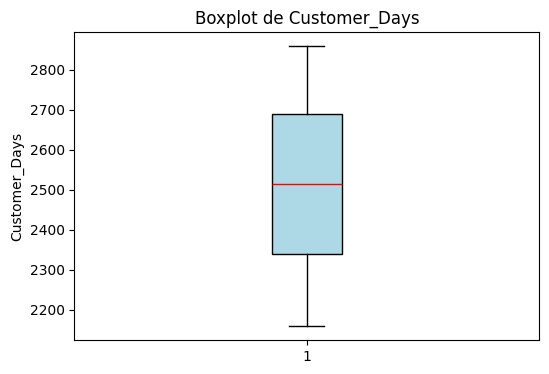

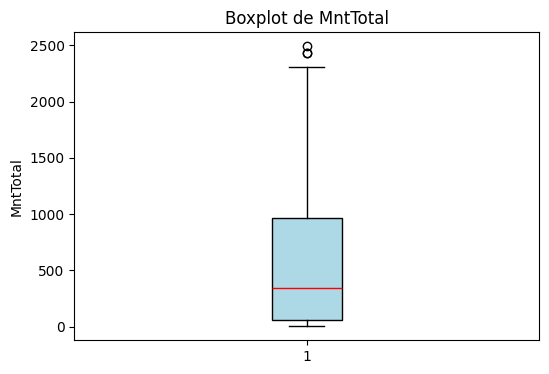

In [45]:
for columna in Columnas_Clave:
    if columna in DC.columns:
        plt.figure(figsize=(6, 4))
        plt.boxplot(DC[columna].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="lightblue"),
                    medianprops=dict(color="red"))
        plt.title(f"Boxplot de {columna}")
        plt.ylabel(columna)
        plt.show()

## Outliers en MntTotal según composición familiar



### **Valores atípicos en datos familiares**

In [83]:
if "TotalHijos" not in DC.columns:
    DC["TotalHijos"] = DC["Kidhome"].fillna(0).astype(int) + DC["Teenhome"].fillna(0).astype(int)

variables = ["Kidhome", "Teenhome", "TotalHijos"]
resultados = []

for var in variables:
    for valor in sorted(DC[var].dropna().unique()):
        grupo = DC[DC[var] == valor]
        n_grupo = grupo.shape[0]
        if n_grupo == 0:
            continue

        Q1 = grupo["MntTotal"].quantile(0.25)
        Q3 = grupo["MntTotal"].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR

        
        outliers = grupo[(grupo["MntTotal"] < lim_inf) | (grupo["MntTotal"] > lim_sup)]

        resultados.append({
            "GrupoFamiliar": var,            
            "Cantidad": valor,               
            "Clientes en grupo": n_grupo,
            "Outliers (count)": outliers.shape[0],
            "Outliers (%)": round(outliers.shape[0] / n_grupo * 100, 2),
            "Suma MntTotal outliers": round(outliers["MntTotal"].sum(), 2),
            "Limite_Inf": round(lim_inf, 2),
            "Limite_Sup": round(lim_sup, 2)
        })

if "TotalHijos" not in DC.columns:
    DC["TotalHijos"] = DC["Kidhome"].fillna(0).astype(int) + DC["Teenhome"].fillna(0).astype(int)

variables = ["Kidhome", "Teenhome", "TotalHijos"]
resultados = []

for var in variables:
    for valor in sorted(DC[var].dropna().unique()):
        grupo = DC[DC[var] == valor]
        n_grupo = grupo.shape[0]
        if n_grupo == 0:
            continue

        Q1 = grupo["MntTotal"].quantile(0.25)
        Q3 = grupo["MntTotal"].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR

        outliers = grupo[(grupo["MntTotal"] < lim_inf) | (grupo["MntTotal"] > lim_sup)]

        resultados.append({
            "GrupoFamiliar": var,              
            "Cantidad": valor,                
            "Clientes en grupo": n_grupo,
            "Outliers (count)": outliers.shape[0],
            "Outliers (%)": round(outliers.shape[0] / n_grupo * 100, 2),
            "Suma MntTotal outliers": round(outliers["MntTotal"].sum(), 2),
            "Limite_Inf": round(lim_inf, 2),
            "Limite_Sup": round(lim_sup, 2)
        })


res_df = pd.DataFrame(resultados).sort_values(["GrupoFamiliar", "Cantidad"])
res_df
res_df = pd.DataFrame(resultados).sort_values(["GrupoFamiliar", "Cantidad"])
res_df

,GrupoFamiliar,Cantidad,Clientes en grupo,Outliers (count),Outliers (%),Suma MntTotal outliers,Limite_Inf,Limite_Sup
0,Kidhome,0,1276,0,0.00,0.0,-994.00,2576.00
1,Kidhome,1,883,98,11.10,87456.0,-221.75,460.25
2,Kidhome,2,46,7,15.22,3193.0,-139.38,279.62
3,Teenhome,0,1139,0,0.00,0.0,-1713.50,2978.50
4,Teenhome,1,1015,6,0.59,11598.0,-990.50,1837.50
5,Teenhome,2,51,0,0.00,0.0,-930.50,1877.50
6,TotalHijos,0,628,0,0.00,0.0,-893.25,2944.75
7,TotalHijos,1,1112,7,0.63,13466.0,-1018.38,1830.62
8,TotalHijos,2,415,33,7.95,32910.0,-347.25,682.75
9,TotalHijos,3,50,5,10.00,6539.0,-310.38,592.62


### Outliers de Gasto total del cliente ```MntTotal``` por total Hijos ```TotalHijos``` 

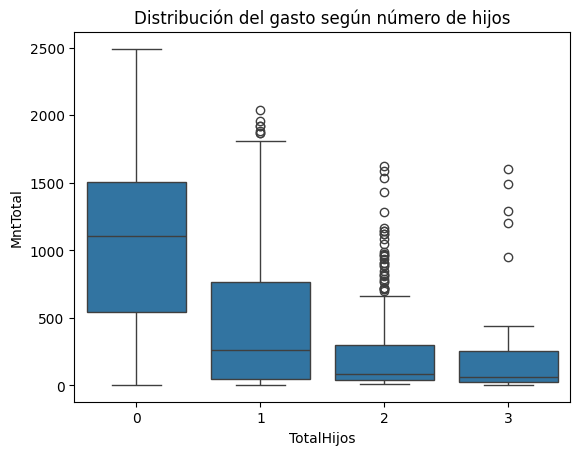

In [46]:
if "TotalHijos" not in DC.columns:
    DC["TotalHijos"] = DC["Kidhome"] + DC["Teenhome"]

sns.boxplot(x="TotalHijos", y="MntTotal", data=DC)
plt.title("Distribución del gasto según número de hijos")
plt.show()


In [76]:
for valor in sorted(DC["TotalHijos"].unique()):
    grupo = DC[DC["TotalHijos"] == valor][["MntTotal", "Income"]]
    if len(grupo) > 1:  # necesita al menos 2 filas
        corr = grupo.corr()
        print(f"\nTotalHijos = {valor} (n={len(grupo)})")
        print(corr.to_string())



TotalHijos = 0 (n=628)
          MntTotal    Income
MntTotal  1.000000  0.799826
Income    0.799826  1.000000

TotalHijos = 1 (n=1112)
          MntTotal   Income
MntTotal   1.00000  0.79435
Income     0.79435  1.00000

TotalHijos = 2 (n=415)
          MntTotal    Income
MntTotal  1.000000  0.713923
Income    0.713923  1.000000

TotalHijos = 3 (n=50)
          MntTotal    Income
MntTotal  1.000000  0.790655
Income    0.790655  1.000000


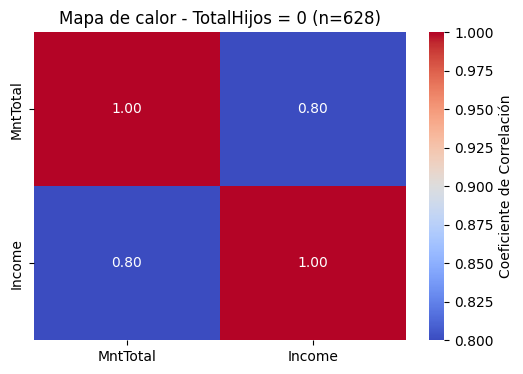

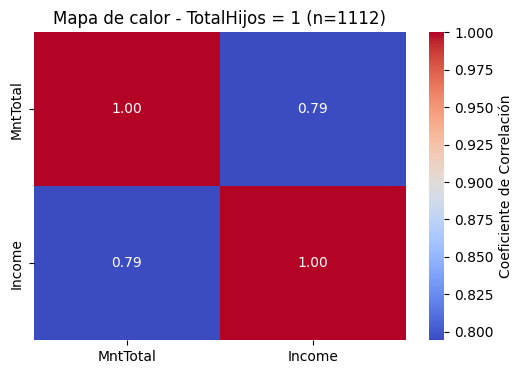

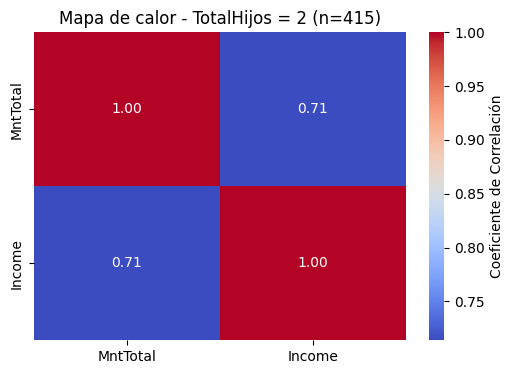

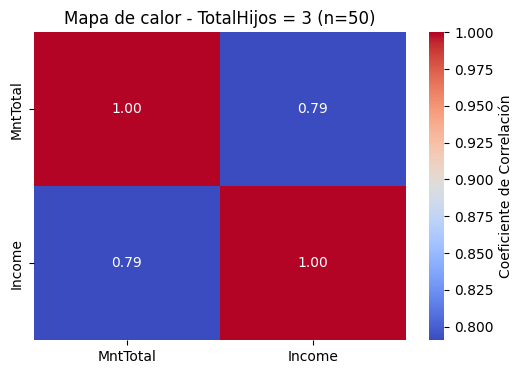

In [82]:
for valor in sorted(DC["TotalHijos"].unique()):
    grupo = DC[DC["TotalHijos"] == valor][["MntTotal", "Income"]]
    if len(grupo) > 1:  # necesita al menos 2 filas
        corr = grupo.corr()
        
        plt.figure(figsize=(6,4))
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={'label': 'Coeficiente de Correlación'}
        )
        plt.title(f"Mapa de calor - TotalHijos = {valor} (n={len(grupo)})")
        plt.show()

In [90]:
outliers_TotalHijos = pd.DataFrame()
for valor in DC['TotalHijos'].unique():
    grupo = DC[DC['TotalHijos'] == valor]
    q1 = grupo['MntTotal'].quantile(0.25)
    q3 = grupo['MntTotal'].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_temp = grupo[(grupo['MntTotal'] < lim_inf) | (grupo['MntTotal'] > lim_sup)].copy()
    outliers_temp = outliers_temp.assign(Grupo='TotalHijos', ValorGrupo=valor)

    outliers_TotalHijos = pd.concat([outliers_TotalHijos, outliers_temp[DC.columns]], ignore_index=True)

outliers_TotalHijos[["id_cliente","Income","Kidhome","Teenhome","TotalHijos","Age","Customer_Days","MntTotal","Marital_Status","Education"]]

,id_cliente,Income,Kidhome,Teenhome,TotalHijos,Age,Customer_Days,MntTotal,Marital_Status,Education
0,46,72550.0,1,1,2,66,2757,1281.0,Married,PhD
1,99,52413.0,0,2,2,51,2671,845.0,Married,Graduation
2,135,59809.0,0,2,2,44,2778,828.0,Married,Graduation
3,210,77622.0,0,2,2,50,2235,700.0,Together,PhD
4,241,75702.0,1,1,2,53,2828,1118.0,Together,Graduation
5,248,69674.0,0,2,2,52,2562,821.0,Divorced,PhD
6,274,50898.0,1,1,2,64,2696,724.0,Together,Master
7,320,62204.0,0,2,2,60,2814,807.0,Divorced,Graduation
8,373,83664.0,1,1,2,52,2576,1087.0,Divorced,PhD
9,403,49505.0,1,1,2,49,2640,723.0,Married,Master


In [96]:
outliers_TotalHijos["Marital_Status"].value_counts()

Marital_Status
Together    18
Married     17
Divorced     5
Single       4
Widow        1
Name: count, dtype: int64

In [97]:
outliers_TotalHijos["Education"].value_counts()

Education
Graduation    22
PhD           11
Master         9
2n Cycle       3
Name: count, dtype: int64

### Outliers de Gasto total del cliente ```MntTotal``` por Total Niños ```Kidhome``` 

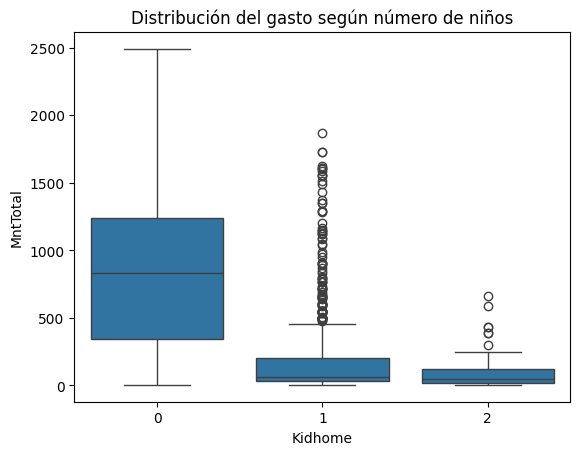

In [50]:
sns.boxplot(x="Kidhome", y="MntTotal", data=DC)
plt.title("Distribución del gasto según número de niños")
plt.show()

In [78]:
for valor in sorted(DC["Kidhome"].unique()):
    grupo = DC[DC["Kidhome"] == valor][["MntTotal", "Income"]]
    if len(grupo) > 1:  # necesita al menos 2 filas
        corr = grupo.corr()
        print(f"\nKidhome = {valor} (n={len(grupo)})")
        print(corr.to_string())


Kidhome = 0 (n=1276)
          MntTotal    Income
MntTotal  1.000000  0.775973
Income    0.775973  1.000000

Kidhome = 1 (n=883)
          MntTotal    Income
MntTotal  1.000000  0.693909
Income    0.693909  1.000000

Kidhome = 2 (n=46)
          MntTotal    Income
MntTotal  1.000000  0.649896
Income    0.649896  1.000000


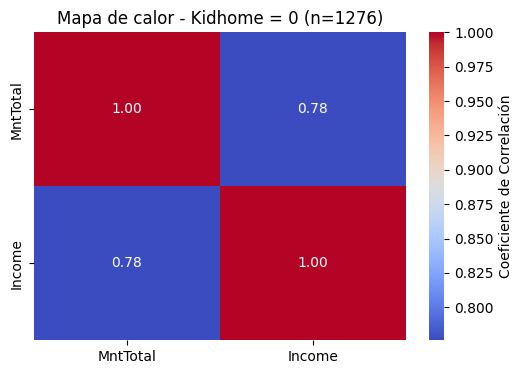

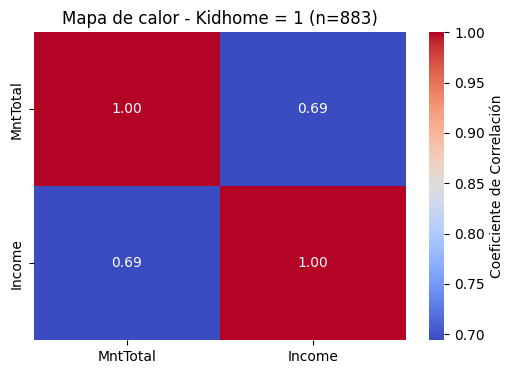

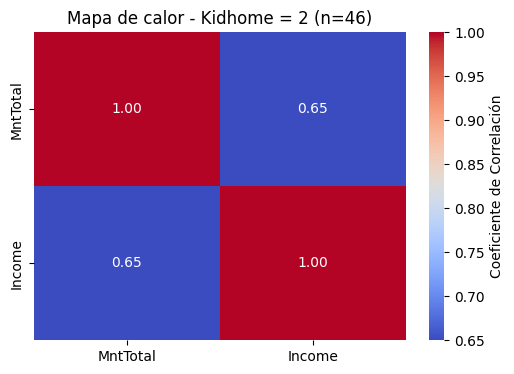

In [81]:
for valor in sorted(DC["Kidhome"].unique()):
    grupo = DC[DC["Kidhome"] == valor][["MntTotal", "Income"]]
    if len(grupo) > 1:  # necesita al menos 2 filas
        corr = grupo.corr()
        
        plt.figure(figsize=(6,4))
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={'label': 'Coeficiente de Correlación'}
        )
        plt.title(f"Mapa de calor - Kidhome = {valor} (n={len(grupo)})")
        plt.show()

In [87]:
outliers_kidhome = pd.DataFrame()
for valor in DC['Kidhome'].unique():
    grupo = DC[DC['Kidhome'] == valor]
    q1 = grupo['MntTotal'].quantile(0.25)
    q3 = grupo['MntTotal'].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_temp = grupo[(grupo['MntTotal'] < lim_inf) | (grupo['MntTotal'] > lim_sup)].copy()
    outliers_temp = outliers_temp.assign(Grupo='Kidhome', ValorGrupo=valor)

    outliers_kidhome = pd.concat([outliers_kidhome, outliers_temp[DC.columns]], ignore_index=True)

outliers_kidhome[["id_cliente","Income","Kidhome","Teenhome","TotalHijos","Age","Customer_Days","MntTotal","Marital_Status","Education"]]

,id_cliente,Income,Kidhome,Teenhome,TotalHijos,Age,Customer_Days,MntTotal,Marital_Status,Education
0,21,2447.0,1,0,1,41,2698,1729.0,Married,Graduation
1,46,72550.0,1,1,2,66,2757,1281.0,Married,PhD
2,51,66373.0,1,1,2,42,2541,497.0,Married,Graduation
3,57,66653.0,1,1,2,45,2819,606.0,Together,Graduation
4,65,74854.0,1,2,3,50,2606,1489.0,Together,Graduation
...,...,...,...,...,...,...,...,...,...,...
100,838,55357.0,2,0,2,35,2654,663.0,Married,Graduation
101,958,56962.0,2,1,3,55,2420,385.0,Married,Master
102,1303,37774.0,2,0,2,43,2823,297.0,Single,Graduation
103,1463,64014.0,2,1,3,74,2178,436.0,Together,PhD


In [98]:
outliers_kidhome["Marital_Status"].value_counts()

Marital_Status
Married     50
Together    32
Single      14
Divorced     7
Widow        2
Name: count, dtype: int64

In [99]:
outliers_kidhome["Education"].value_counts()

Education
Graduation    54
Master        24
PhD           19
2n Cycle       8
Name: count, dtype: int64

### Outliers de Gasto total del cliente ```MntTotal``` por Total Adolecentes ```Teenhome```

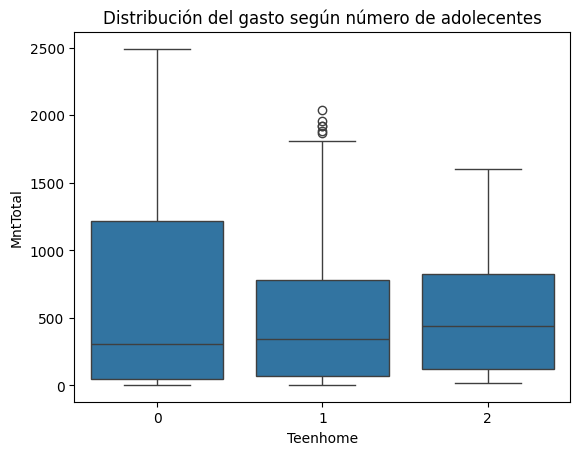

In [51]:
sns.boxplot(x="Teenhome", y="MntTotal", data=DC)
plt.title("Distribución del gasto según número de adolecentes")
plt.show()

In [79]:
for valor in sorted(DC["Teenhome"].unique()):
    grupo = DC[DC["Teenhome"] == valor][["MntTotal", "Income"]]
    if len(grupo) > 1:  # necesita al menos 2 filas
        corr = grupo.corr()
        print(f"\nTeenhome = {valor} (n={len(grupo)})")
        print(corr.to_string())


Teenhome = 0 (n=1139)
          MntTotal    Income
MntTotal  1.000000  0.870506
Income    0.870506  1.000000

Teenhome = 1 (n=1015)
          MntTotal    Income
MntTotal  1.000000  0.757445
Income    0.757445  1.000000

Teenhome = 2 (n=51)
          MntTotal    Income
MntTotal  1.000000  0.762545
Income    0.762545  1.000000


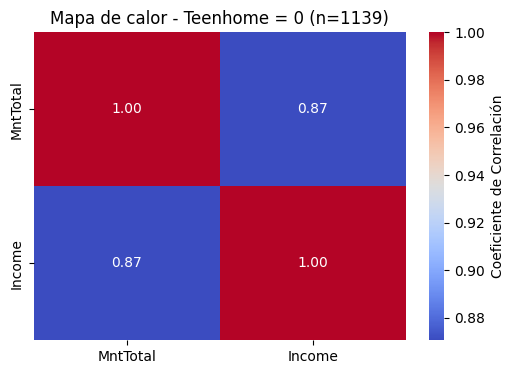

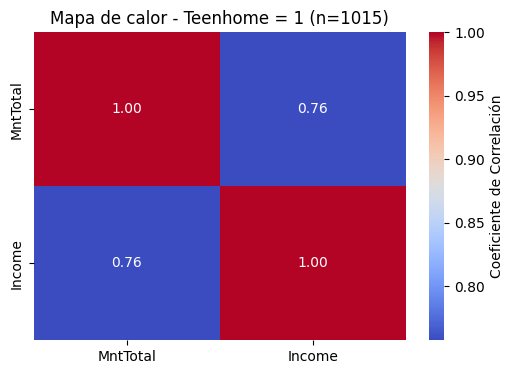

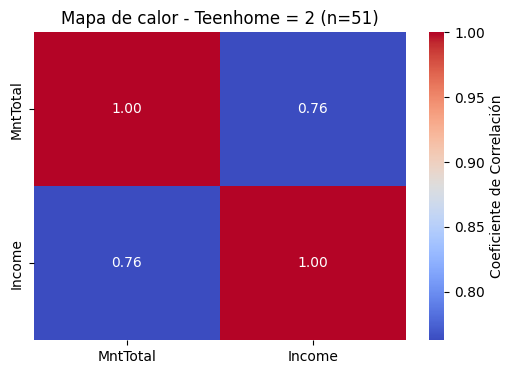

In [80]:
for valor in sorted(DC["Teenhome"].unique()):
    grupo = DC[DC["Teenhome"] == valor][["MntTotal", "Income"]]
    if len(grupo) > 1:  # necesita al menos 2 filas
        corr = grupo.corr()
        
        plt.figure(figsize=(6,4))
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={'label': 'Coeficiente de Correlación'}
        )
        plt.title(f"Mapa de calor - Teenhome = {valor} (n={len(grupo)})")
        plt.show()

In [86]:
outliers_Teenhome = pd.DataFrame()
for valor in DC['Teenhome'].unique():
    grupo = DC[DC['Teenhome'] == valor]
    q1 = grupo['MntTotal'].quantile(0.25)
    q3 = grupo['MntTotal'].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_temp = grupo[(grupo['MntTotal'] < lim_inf) | (grupo['MntTotal'] > lim_sup)].copy()
    outliers_temp = outliers_temp.assign(Grupo='Teenhome', ValorGrupo=valor)

    outliers_Teenhome = pd.concat([outliers_Teenhome, outliers_temp[DC.columns]], ignore_index=True)

outliers_Teenhome[["id_cliente","Income","Kidhome","Teenhome","TotalHijos","Age","Customer_Days","MntTotal","Marital_Status","Education"]]

,id_cliente,Income,Kidhome,Teenhome,TotalHijos,Age,Customer_Days,MntTotal,Marital_Status,Education
0,474,78952.0,0,1,1,62,2802,1958.0,Together,PhD
1,543,87771.0,0,1,1,61,2562,1924.0,Together,Graduation
2,805,87771.0,0,1,1,61,2562,1924.0,Together,Graduation
3,991,77568.0,0,1,1,41,2832,2036.0,Together,Graduation
4,1114,85606.0,0,1,1,44,2753,1872.0,Together,Graduation
5,1776,75702.0,0,1,1,46,2782,1884.0,Together,Graduation


In [101]:
outliers_Teenhome["Marital_Status"].value_counts()

Marital_Status
Together    6
Name: count, dtype: int64

In [100]:
outliers_Teenhome["Education"].value_counts()

Education
Graduation    5
PhD           1
Name: count, dtype: int64

### **Los Ingresos ```Income``` estan estrechamente relacionados con la cantidad de Gastos ```MntTotal```**

In [47]:
DC[["MntTotal", "Income", "Age", "Kidhome", "Teenhome", "TotalHijos"]].corr()

,MntTotal,Income,Age,Kidhome,Teenhome,TotalHijos
MntTotal,1.000000,0.823066,0.118370,-0.551152,-0.142995,-0.499025
Income,0.823066,1.000000,0.212625,-0.531699,0.042483,-0.350313
Age,0.118370,0.212625,1.000000,-0.238083,0.362919,0.093007
Kidhome,-0.551152,-0.531699,-0.238083,1.000000,-0.040207,0.687697
Teenhome,-0.142995,0.042483,0.362919,-0.040207,1.000000,0.697760
TotalHijos,-0.499025,-0.350313,0.093007,0.687697,0.697760,1.000000


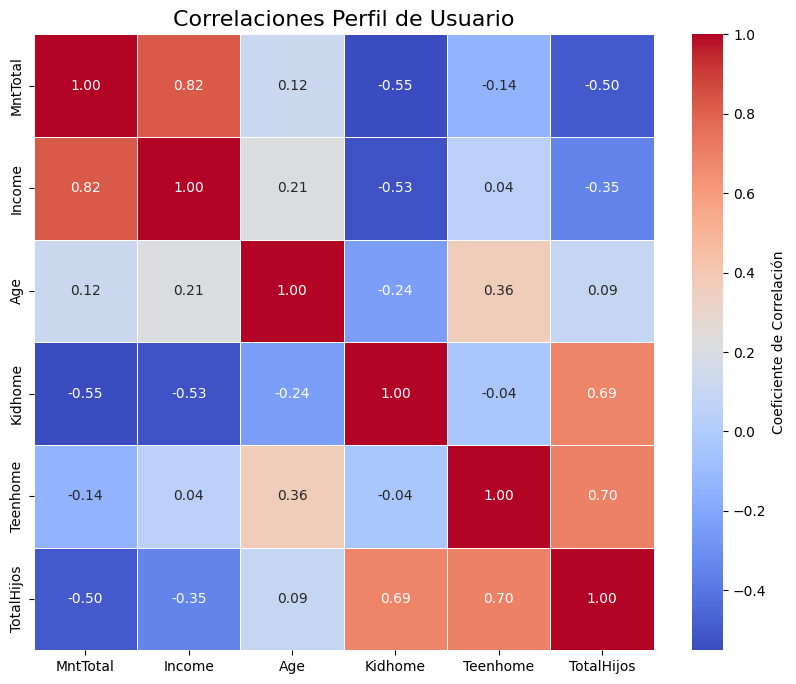

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(
    DC[["MntTotal", "Income", "Age", "Kidhome", "Teenhome", "TotalHijos"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Correlaciones Perfil de Usuario', fontsize=16)
plt.show()

## Exportación del dataset preprocesado para Power BI

In [102]:
DC.to_csv("marketing_clean.csv", index=False)
print("Archivo exportado: marketing_clean.csv")
print(f"Registros: {len(DC)} | Columnas: {len(DC.columns)}")
DC.head()


Archivo exportado: marketing_clean.csv
Registros: 2205 | Columnas: 35


,id_cliente,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,MntTotal,MntRegularProds,AcceptedCmpOverall,Marital_Status,Education,Marital_Status_Code,Education_Code,TotalHijos
0,1,58138.0,0,0,58,635.0,88.0,546.0,172.0,88.0,88.0,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,1529.0,1441,0,Single,Graduation,2,2,0
1,2,46344.0,1,1,38,11.0,1.0,6.0,2.0,1.0,6.0,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,21.0,15,0,Single,Graduation,2,2,2
2,3,71613.0,0,0,26,426.0,49.0,127.0,111.0,21.0,42.0,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,734.0,692,0,Together,Graduation,3,2,0
3,4,26646.0,1,0,26,11.0,4.0,20.0,10.0,3.0,5.0,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,48.0,43,0,Together,Graduation,3,2,1
4,5,58293.0,1,0,94,173.0,43.0,118.0,46.0,27.0,15.0,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,407.0,392,0,Married,PhD,1,4,1
